In [28]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [5]:
feature_summary = (
    X_train.describe()
    .T[['mean', 'std', 'min', 'max']]
    .rename(columns={"mean": "Mean", "std": "Std", "min": "Min", "max": "Max"})
    .round(2)
)
feature_summary


,Mean,Std,Min,Max
mean radius,14.07,3.50,6.98,28.11
mean texture,19.25,4.41,9.71,39.28
mean perimeter,91.56,24.15,43.79,188.50
mean area,648.54,344.94,143.50,2499.00
mean smoothness,0.10,0.01,0.06,0.14
mean compactness,0.10,0.05,0.02,0.35
mean concavity,0.09,0.08,0.00,0.43
mean concave points,0.05,0.04,0.00,0.20
mean symmetry,0.18,0.03,0.11,0.30
mean fractal dimension,0.06,0.01,0.05,0.10


In [6]:
correlation = X_train.corrwith(y_train).sort_values(ascending=False)
correlation


smoothness error           0.070507
texture error              0.023917
mean fractal dimension    -0.001027
symmetry error            -0.012765
fractal dimension error   -0.059216
concavity error           -0.252785
compactness error         -0.291239
worst fractal dimension   -0.327308
mean symmetry             -0.358370
mean smoothness           -0.392200
mean texture              -0.409384
concave points error      -0.418560
worst smoothness          -0.429227
worst symmetry            -0.430422
worst texture             -0.450765
perimeter error           -0.551905
radius error              -0.565074
area error                -0.567197
worst compactness         -0.602331
mean compactness          -0.610722
worst concavity           -0.668368
mean concavity            -0.692052
mean area                 -0.713409
mean radius               -0.732224
worst area                -0.737965
mean perimeter            -0.745132
worst radius              -0.776390
mean concave points       -0

In [7]:
class_balance = pd.DataFrame({
    "count": y_train.value_counts().sort_index(),
    "share": y_train.value_counts(normalize=True).sort_index() * 100
}).rename(index={0: "malignant", 1: "benign"})
class_balance["share"] = class_balance["share"].round(2)
class_balance


,count,share
target,,
malignant,170,37.36
benign,285,62.64


In [16]:
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("tree", DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba_malignant = pipe.predict_proba(X_test)[:, 0]  # вероятность класса 'malignant'


In [17]:
y_test_malignant = (y_test == 0).astype(int)
y_pred_malignant = (y_pred == 0).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test_malignant, y_pred_malignant)
rec = recall_score(y_test_malignant, y_pred_malignant)
f1 = f1_score(y_test_malignant, y_pred_malignant)
auc = roc_auc_score(y_test_malignant, y_proba_malignant)

print(f"Accuracy: {acc:.3f}")
print(f"Precision (malignant): {prec:.3f}")
print(f"Recall (malignant): {rec:.3f}")
print(f"F1-score (malignant): {f1:.3f}")
print(f"ROC-AUC (malignant): {auc:.3f}")


Accuracy: 0.912
Precision (malignant): 0.848
Recall (malignant): 0.929
F1-score (malignant): 0.886
ROC-AUC (malignant): 0.916


In [18]:
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))


              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



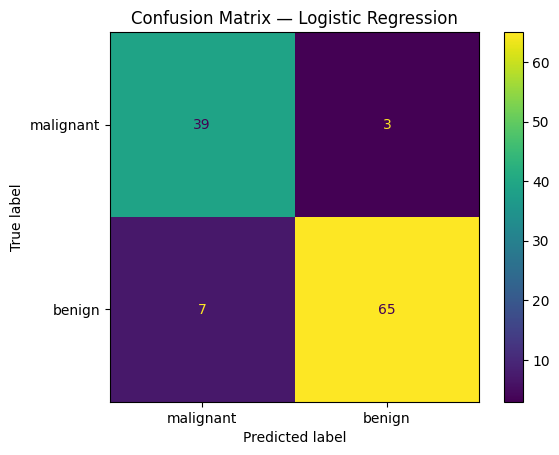

In [19]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"])
disp.plot(values_format='d')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


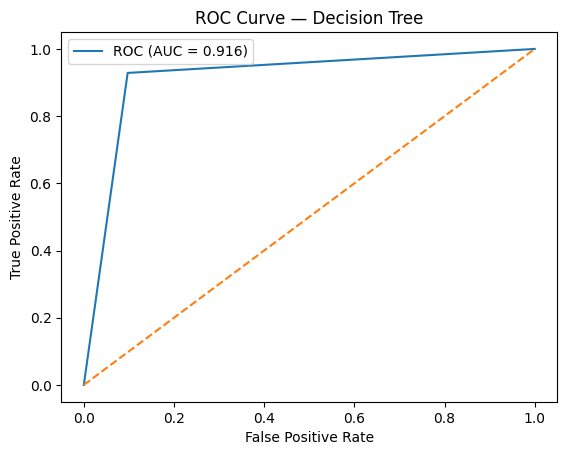

In [20]:
fpr, tpr, thr = roc_curve(y_test_malignant, y_proba_malignant)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree")
plt.legend()
plt.show()


In [ ]:
imp = pd.DataFrame({"feature":X.columns, "importance":pipe.named_steps["tree"].feature_importances_}).sort_values("importance", ascending=False)
imp.head(10)

,feature,importance
20,worst radius,0.697811
27,worst concave points,0.116083
21,worst texture,0.058881
11,texture error,0.052661
26,worst concavity,0.016325
23,worst area,0.012678
13,area error,0.012085
28,worst symmetry,0.010733
24,worst smoothness,0.008452
7,mean concave points,0.006261


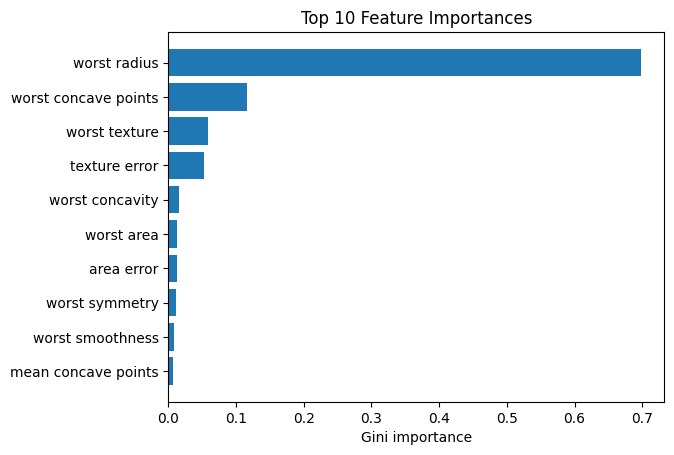

In [26]:
plt.figure()
plt.barh(imp.head(10)["feature"], imp.head(10)["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Gini importance")
plt.show()

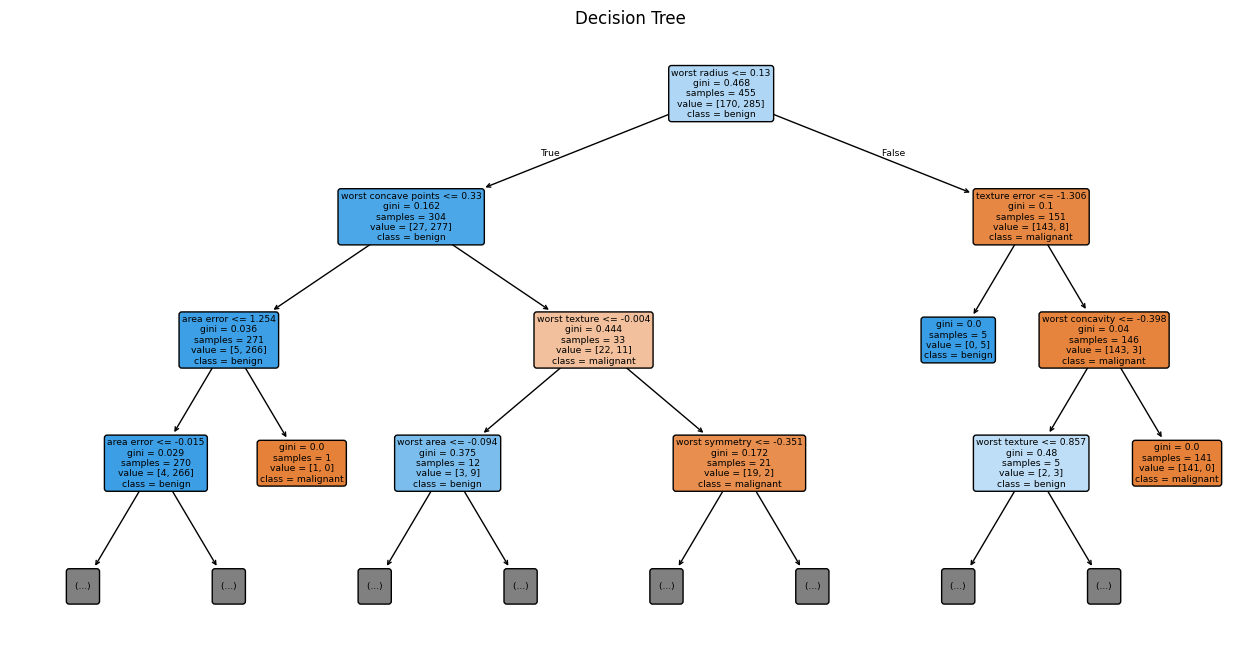

In [31]:
plt.figure(figsize=(16,8))
plot_tree(pipe.named_steps["tree"], feature_names=X.columns, class_names=["malignant", "benign"], filled=True, rounded=True, impurity=True, max_depth=3)
plt.title("Decision Tree")
plt.show()